# 02 – Feature Engineering & Model Development

## Notebook Objectives
- Feature preparation (feature engineering and preprocessing)
- Model development
  - Building a machine learning pipeline
  - Training multiple models
  - Evaluation using different metrics (MAE, RMSE, and R²)

In [1]:
# Projekt-Root zum Pfad hinzufügen
import sys
sys.path.append("..") # damit src/ Module gefunden werden


In [2]:
# Imports

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data import load_sample_listings
from src.features import add_amenity_count
from src.train_model import (
    get_train_test_data,
    train_all_models,
)
from src.evaluate import evaluate_models

In [3]:
# Daten laden & aufbereiten

df = load_sample_listings()
df.head()

,price,neighbourhood,room_type,minimum_nights,number_of_reviews,review_scores_rating,amenities,latitude,longitude
0,205.0,I Centro Storico,Entire home/apt,1,59,4.68,"[""Hangers"", ""Pack \u2019n play/Travel crib"", ""...",41.877946,12.473666
1,149.0,VIII Appia Antica,Entire home/apt,3,13,5.00,"[""Hangers"", ""Carbon monoxide alarm"", ""Clothing...",41.860463,12.483244
2,67.0,XIII Aurelia,Entire home/apt,1,94,4.95,"[""Heating"", ""Free parking on premises"", ""Clean...",41.894668,12.447176
3,102.0,I Centro Storico,Private room,5,435,4.80,"[""Air conditioning"", ""Hangers"", ""Wifi"", ""Host ...",41.894140,12.506500
4,140.0,I Centro Storico,Entire home/apt,2,54,4.76,"[""Hangers"", ""Pack \u2019n play/Travel crib"", ""...",41.912990,12.455640


In [4]:
# Feature Engineering

# Generiere eines neuen Features (Anzahl der Ausstattungsmerkmale)
# Hypothese: Anzahl der Ausstattungsmerkmale (amenities) beeinflusst den Preis

df_model = add_amenity_count(df)
df_model.head()

,price,neighbourhood,room_type,minimum_nights,number_of_reviews,review_scores_rating,latitude,longitude,amenity_count
0,205.0,I Centro Storico,Entire home/apt,1,59,4.68,41.877946,12.473666,53
1,149.0,VIII Appia Antica,Entire home/apt,3,13,5.00,41.860463,12.483244,50
2,67.0,XIII Aurelia,Entire home/apt,1,94,4.95,41.894668,12.447176,32
3,102.0,I Centro Storico,Private room,5,435,4.80,41.894140,12.506500,18
4,140.0,I Centro Storico,Entire home/apt,2,54,4.76,41.912990,12.455640,37


In [5]:

# Trainings- und Testdaten generieren
X_train, X_test, y_train, y_test = get_train_test_data()

X_train.head()



,neighbourhood,room_type,minimum_nights,number_of_reviews,review_scores_rating,latitude,longitude,amenity_count
9839,I Centro Storico,Entire home/apt,1,89,4.87,41.910920,12.473990,41
9680,XIII Aurelia,Entire home/apt,1,10,4.30,41.897421,12.436473,39
7093,I Centro Storico,Entire home/apt,2,18,4.83,41.907696,12.452045,48
11293,I Centro Storico,Entire home/apt,3,1,5.00,41.875410,12.487580,12
820,VIII Appia Antica,Entire home/apt,3,8,4.75,41.864680,12.484970,55


In [6]:
# Modelle trainieren

results = train_all_models()


Training: RandomForest (Original-Target)
Metriken RF: {'rmse': np.float64(65.52878106534436), 'mae': 46.35658234126984, 'r2': 0.363360716226245}

Training: RandomForest (log-Target)
Metriken RF-Log: {'rmse': np.float64(64.77010109522897), 'mae': 43.749461411565434, 'r2': 0.3780171585244666}

Training: XGBRegressor (log-Target)
Metriken XGB-Log: {'rmse': np.float64(64.90565664934293), 'mae': 44.02324371210734, 'r2': 0.37541097277791846}


In [7]:
# Modelle evaluieren

results, _ = evaluate_models()

# Modellnamen für bessere Lesbarkeit
name_map = {
    "rf": "RandomForest",
    "rf_log": "RandomForest (Log)",
    "xgb_log": "XGBoost (Log)",
}

# Tabelle vorbereiten
rows = []
for key, m in results.items():
    rows.append({
        "Modell": name_map.get(key, key),
        "RMSE": m["rmse"],
        "MAE": m["mae"],
        "R²": m["r2"],
    })

# DataFrame erstellen und formatieren
metrics_df = pd.DataFrame(rows)
metrics_df.style.format({
    "RMSE": "{:.2f}",
    "MAE": "{:.2f}",
    "R²": "{:.3f}",
})


Vorhersagen geladen: rf (models/predictions_rf.csv) – 3000 Zeilen
Vorhersagen geladen: rf_log (models/predictions_rf_log.csv) – 3000 Zeilen
Vorhersagen geladen: xgb_log (models/predictions_xgb_log.csv) – 3000 Zeilen

Bestes Modell (nach RMSE): rf_log (RMSE=64.77)


,Modell,RMSE,MAE,R²
0,RandomForest,65.53,46.36,0.363
1,RandomForest (Log),64.77,43.75,0.378
2,XGBoost (Log),64.91,44.02,0.375


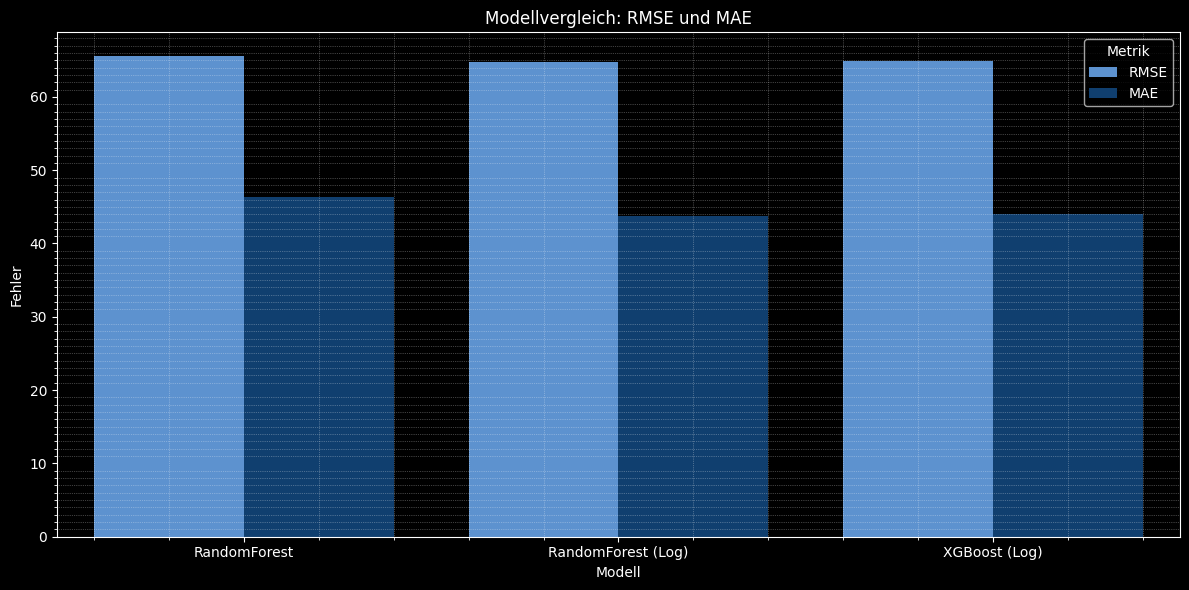

In [8]:
# Visueller Modellvergleich (RMSE und MAE)

# Spalten mit relevanten Metriken
error_metrics = metrics_df[["Modell", "RMSE", "MAE"]]

# Long-Format für Seaborn
error_long = error_metrics.melt(
    id_vars="Modell", 
    value_vars=["RMSE", "MAE"],
    var_name="metric", 
    value_name="value"
)

plt.figure(figsize=(12, 6))

sns.barplot(data=error_long, 
            x="Modell", 
            y="value", 
            hue="metric", 
            palette=["#4A90E2", "#003f7f"]
)

plt.title("Modellvergleich: RMSE und MAE")
plt.ylabel("Fehler")
plt.xlabel("Modell")
plt.legend(title="Metrik")

plt.gca().minorticks_on()
plt.gca().yaxis.set_minor_locator(plt.MultipleLocator(1))
plt.grid(which="minor", linestyle=":", linewidth=0.5, alpha=0.5)

plt.tight_layout()
plt.show()

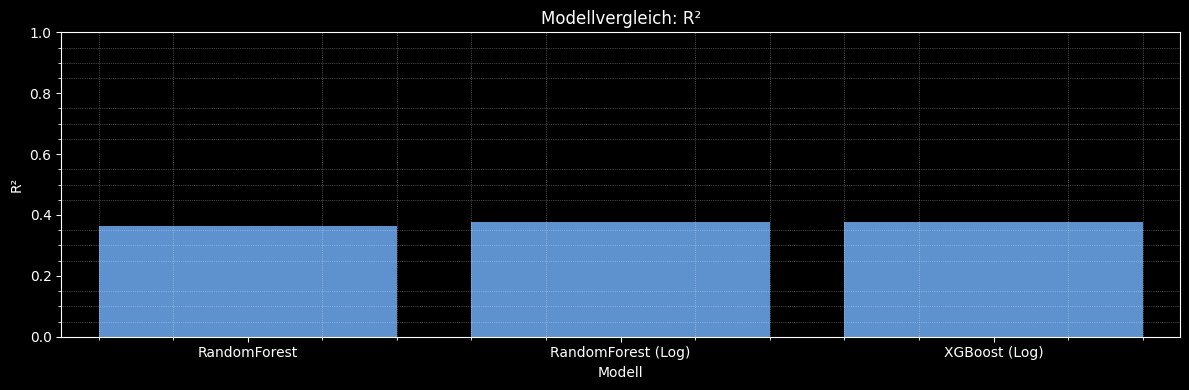

In [9]:
# Visueller Modellvergleich (R²)

r2_metrics = metrics_df[["Modell", "R²"]]

plt.figure(figsize=(12, 4))
sns.barplot(data=r2_metrics, x="Modell", y="R²", color="#4A90E2")
plt.title("Modellvergleich: R²")
plt.ylabel("R²")
plt.xlabel("Modell")
plt.ylim(0, 1)

ax = plt.gca()
ax.minorticks_on()
ax.yaxis.set_minor_locator(plt.MultipleLocator(0.05))

plt.grid(which="minor", linestyle=":", linewidth=0.5, alpha=0.5)
plt.tight_layout()
plt.show()

## Conclusion

- Simple feature engineering was applied to the `amenities` feature
- A machine learning pipeline was built with the following components:
  - Preprocessing with one-hot encoding for categorical features (`neighbourhood`, `room_type`)
  - Train–test split
  - Model evaluation and storage of predictions and metrics
- Multiple models were trained and evaluated:
  - Random Forest Regressor
  - Random Forest Regressor with log-transformed target
  - XGBoost Regressor with log-transformed target
- **Key insight:** Model performance differences are marginal across the evaluated approaches